# **Data Analysis** / **Feature Engineering**

In [1]:
import pandas as pd

df = pd.read_csv("/Users/altair/Applications/aqi-predictor/data/processed/historical_dataset_hourly.csv")


In [2]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'surface_pressure',
       'precipitation', 'wind_speed_10m', 'datetime', 'pm2_5', 'pm10',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'AQI', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'],
      dtype='object')

In [3]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

   temperature_2m  relative_humidity_2m  surface_pressure  precipitation  \
0            10.3                    75             956.8            0.0   
1             8.7                    79             956.3            0.0   
2             8.7                    78             956.1            0.0   
3            10.6                    69             956.8            0.0   
4            10.3                    68             956.6            0.0   

   wind_speed_10m             datetime  pm2_5   pm10  carbon_monoxide  \
0             4.3  2024-01-01 00:00:00   73.3  107.8           2726.0   
1             5.9  2024-01-01 01:00:00   59.5   88.0           2447.0   
2             6.4  2024-01-01 02:00:00   47.6   71.0           2181.0   
3             4.0  2024-01-01 03:00:00   37.8   57.0           1914.0   
4             2.3  2024-01-01 04:00:00   30.2   46.1           1659.0   

   nitrogen_dioxide  sulphur_dioxide  ozone  AQI  hour_sin  hour_cos  \
0              78.4             

In [4]:
print(df.isnull().sum())

temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
precipitation           0
wind_speed_10m          0
datetime                0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
AQI                     0
hour_sin                0
hour_cos                0
month_sin               0
month_cos               0
dtype: int64


In [5]:
print(df.duplicated().sum())

df = df.drop_duplicates()

0


In [6]:
print(df.dtypes)

temperature_2m          float64
relative_humidity_2m      int64
surface_pressure        float64
precipitation           float64
wind_speed_10m          float64
datetime                 object
pm2_5                   float64
pm10                    float64
carbon_monoxide         float64
nitrogen_dioxide        float64
sulphur_dioxide         float64
ozone                   float64
AQI                       int64
hour_sin                float64
hour_cos                float64
month_sin               float64
month_cos               float64
dtype: object


In [7]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [8]:
print(df.dtypes)

temperature_2m                 float64
relative_humidity_2m             int64
surface_pressure               float64
precipitation                  float64
wind_speed_10m                 float64
datetime                datetime64[ns]
pm2_5                          float64
pm10                           float64
carbon_monoxide                float64
nitrogen_dioxide               float64
sulphur_dioxide                float64
ozone                          float64
AQI                              int64
hour_sin                       float64
hour_cos                       float64
month_sin                      float64
month_cos                      float64
dtype: object


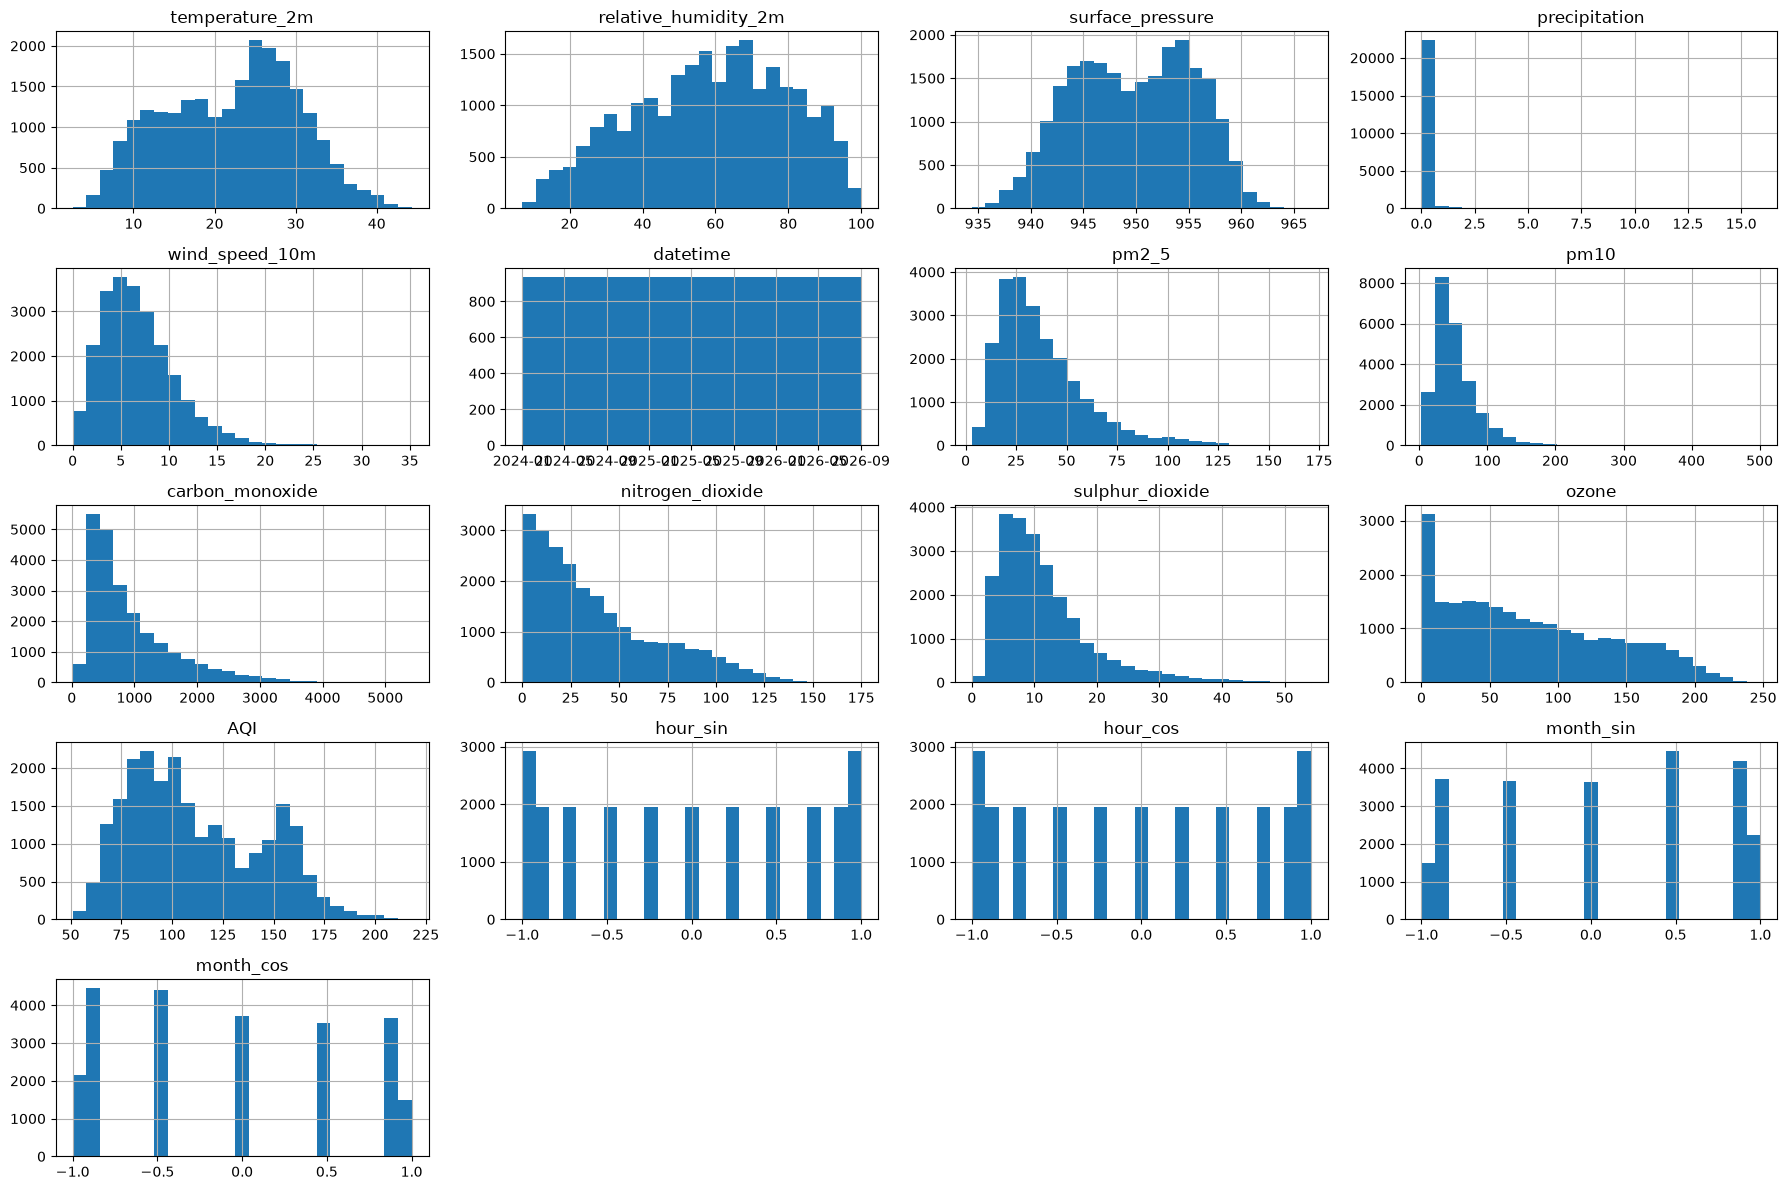

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(18,12), bins=25)

plt.tight_layout()

plt.show()

## **Analysis**
### Skewed Features. some are positive but are valid because there are some conditions in which values can be high based on the weather condition. 
### in some features there are 2 peaks those are also valid because our data is of 2 years. 

In [10]:
print(df.skew(numeric_only=True))

temperature_2m         -9.007537e-02
relative_humidity_2m   -2.204727e-01
surface_pressure       -8.676924e-02
precipitation           9.422087e+00
wind_speed_10m          1.159697e+00
pm2_5                   1.412701e+00
pm10                    2.207525e+00
carbon_monoxide         1.599863e+00
nitrogen_dioxide        9.673137e-01
sulphur_dioxide         1.661239e+00
ozone                   4.833850e-01
AQI                     4.596994e-01
hour_sin                1.098277e-16
hour_cos                1.149759e-16
month_sin              -1.424619e-01
month_cos               1.684324e-01
dtype: float64


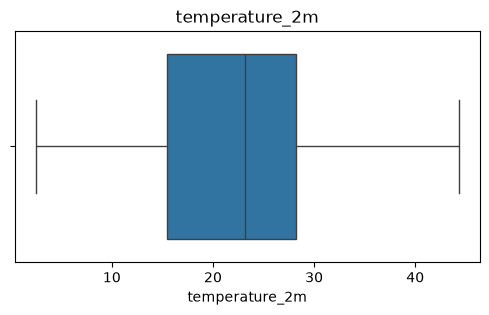

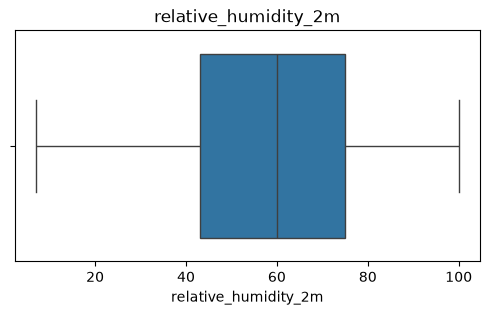

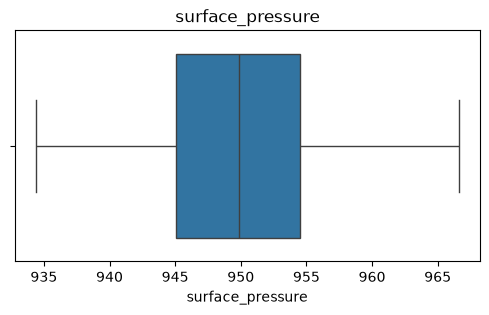

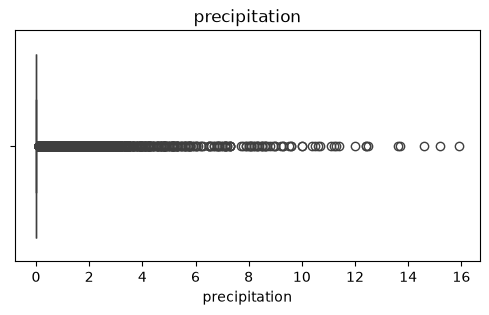

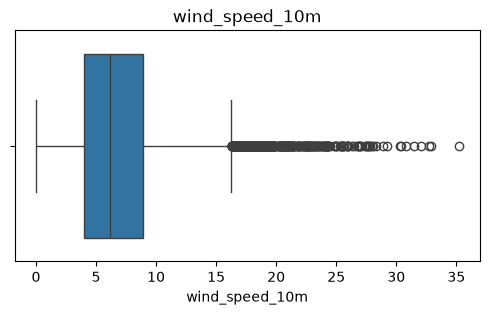

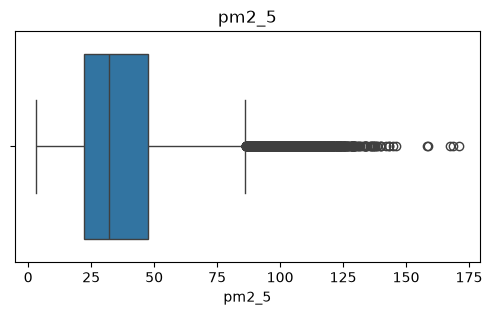

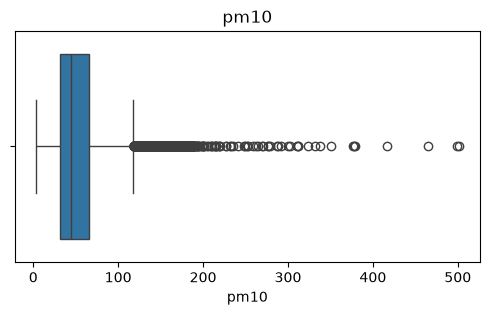

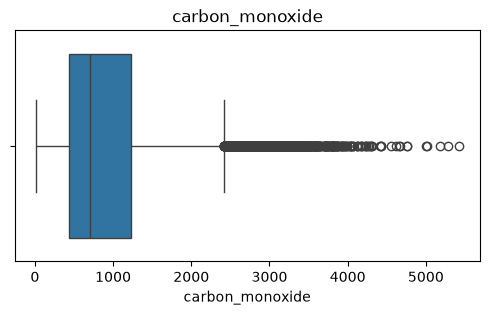

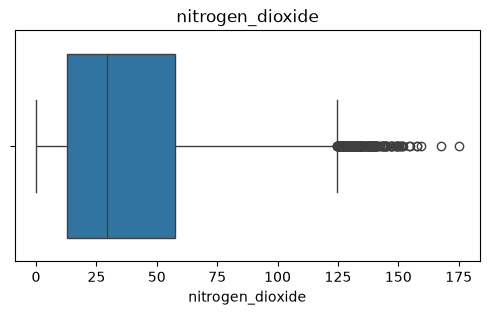

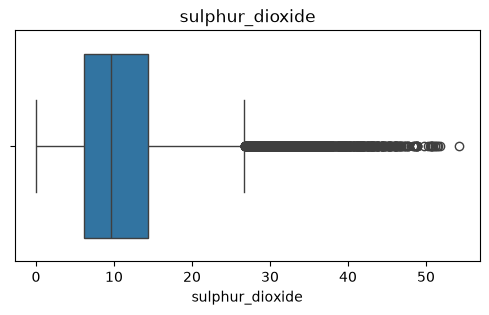

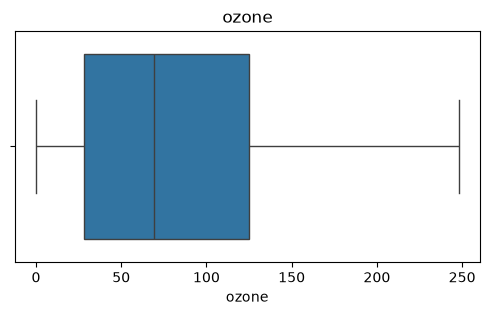

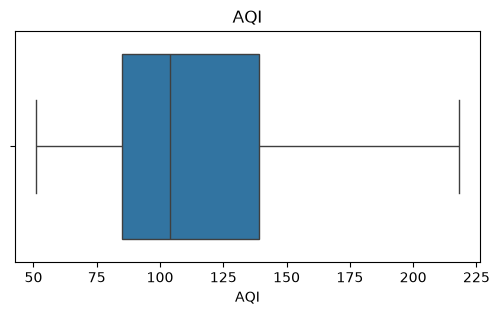

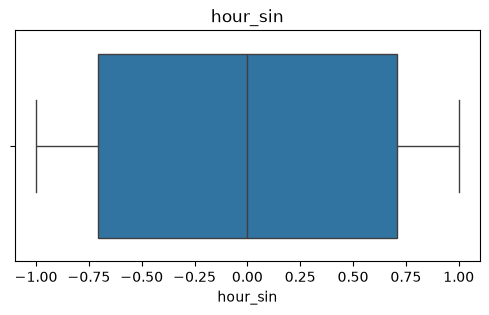

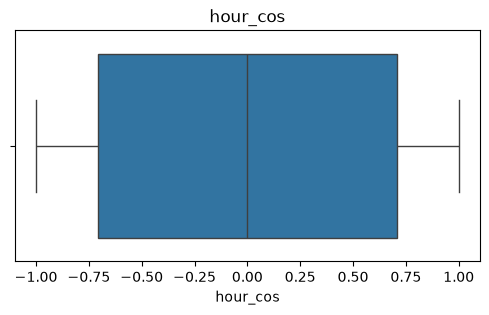

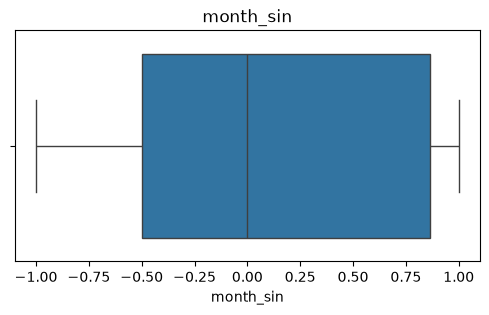

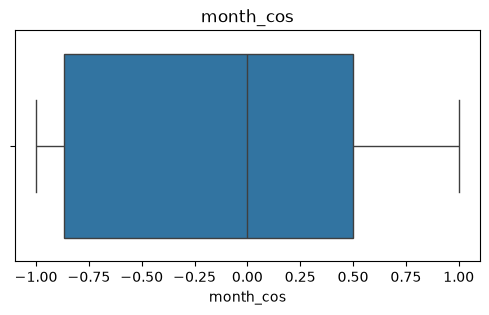

In [11]:
import seaborn as sns
for column in df.select_dtypes(include="number"):

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

## **Analysis**
### AQI naturally contains extreme pollution events, So no need to consider extreme values as outliers

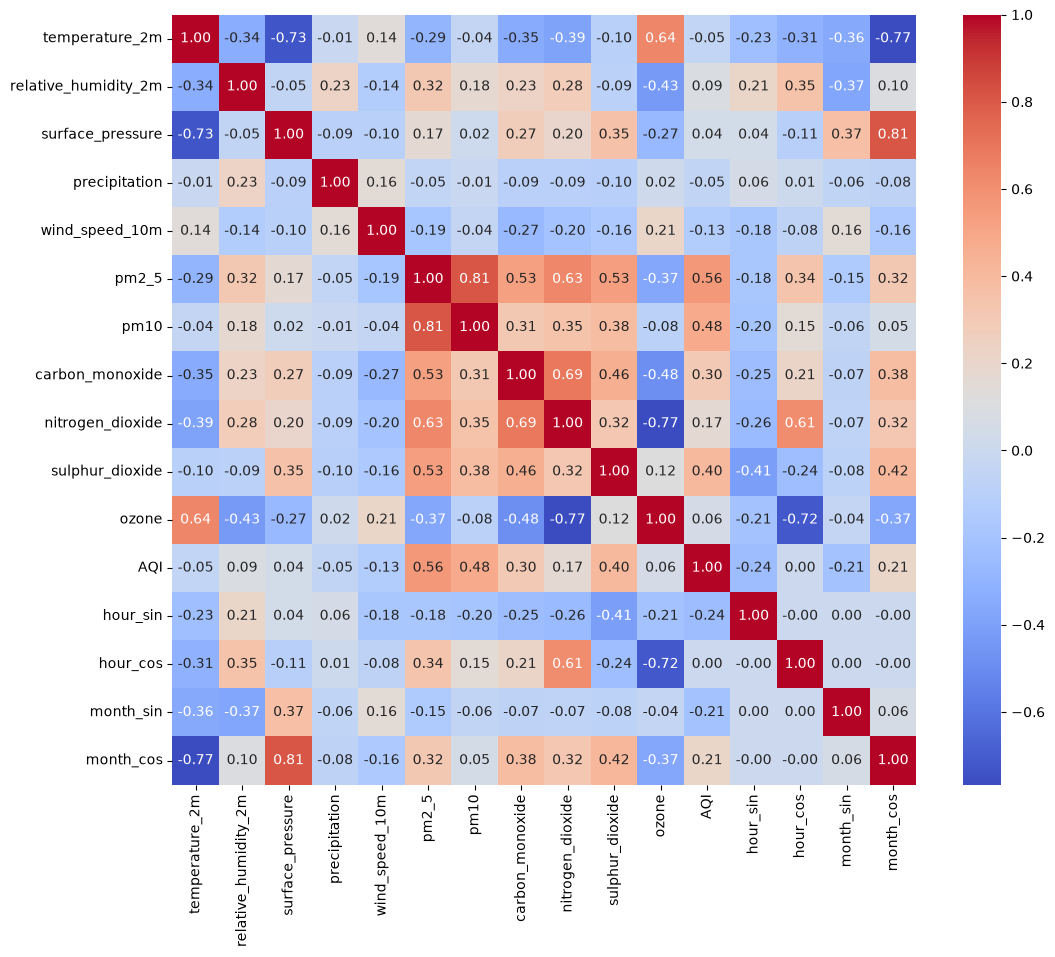

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

## **Analysis**
### We can combine temperature_2m_max,temperature_2m_min,temperature_2m_mean because they are highly correlated. But combining them or not depends on the modeel we are using to train

In [13]:
corr = df.corr(numeric_only=True)["AQI"]

print(corr.sort_values())

hour_sin               -0.243120
month_sin              -0.210385
wind_speed_10m         -0.132551
precipitation          -0.049692
temperature_2m         -0.049026
hour_cos                0.003371
surface_pressure        0.043053
ozone                   0.061338
relative_humidity_2m    0.092686
nitrogen_dioxide        0.170224
month_cos               0.213055
carbon_monoxide         0.303180
sulphur_dioxide         0.404317
pm10                    0.481103
pm2_5                   0.562941
AQI                     1.000000
Name: AQI, dtype: float64


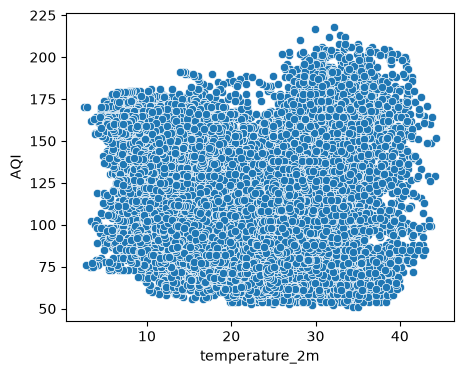

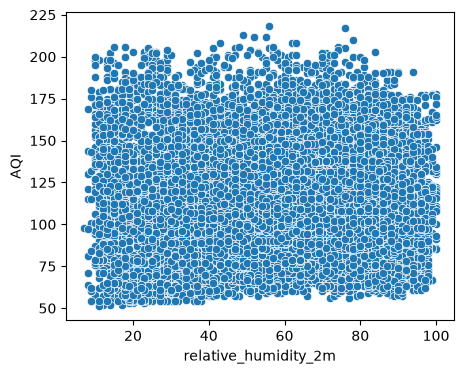

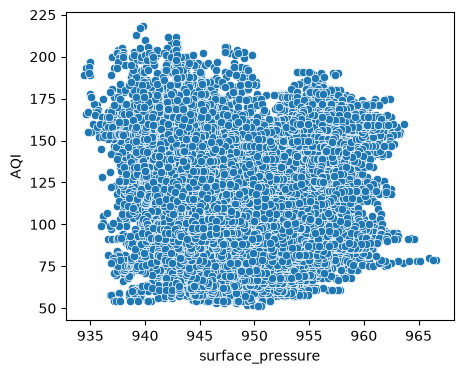

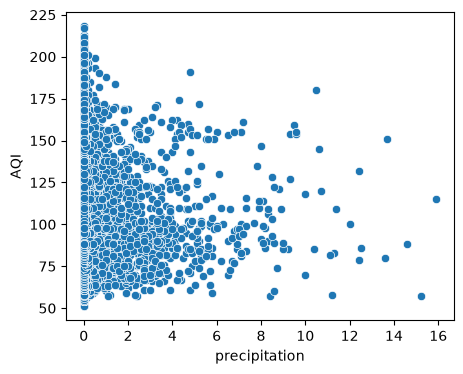

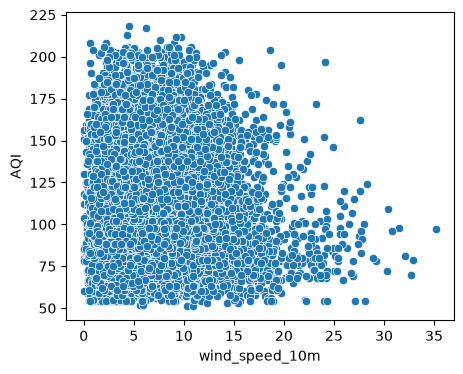

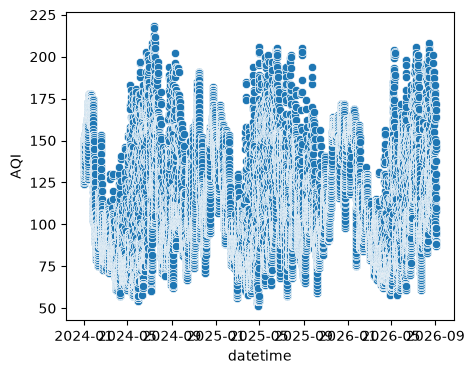

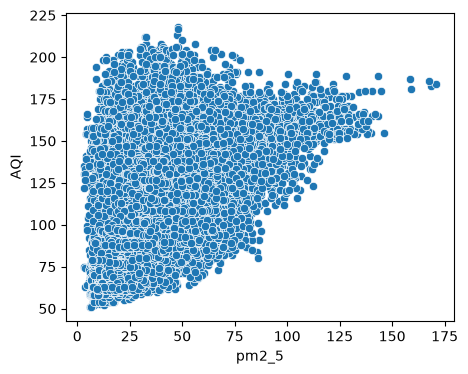

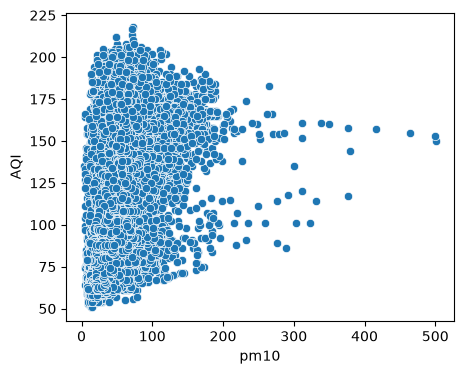

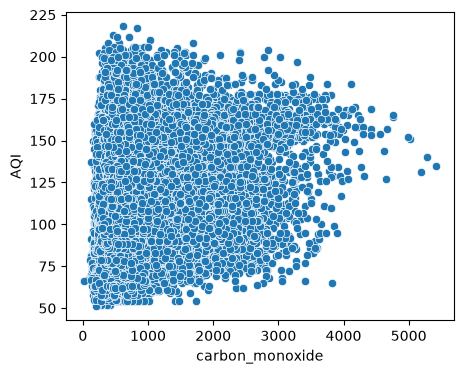

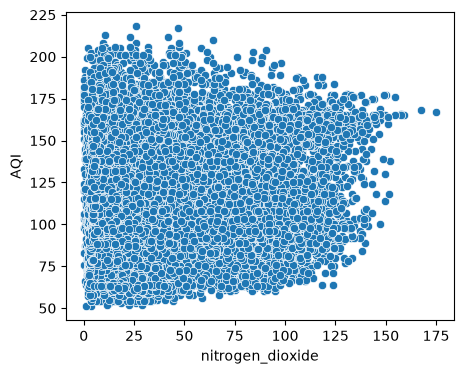

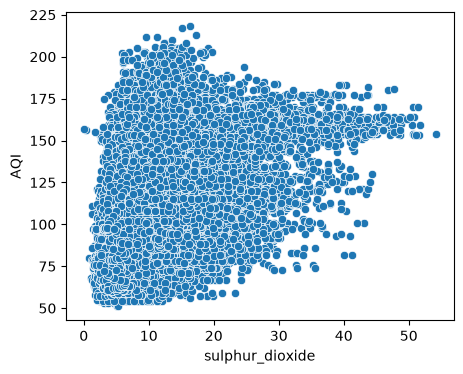

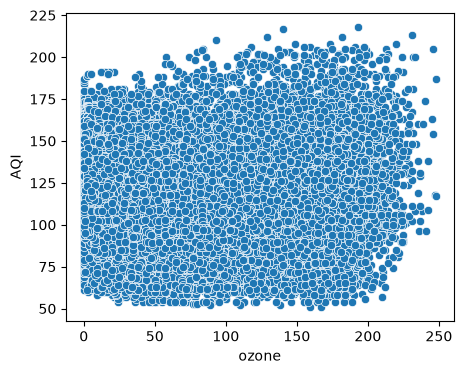

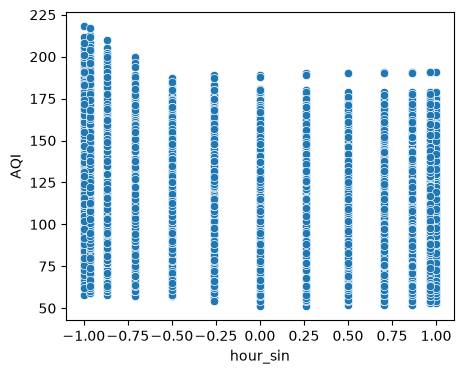

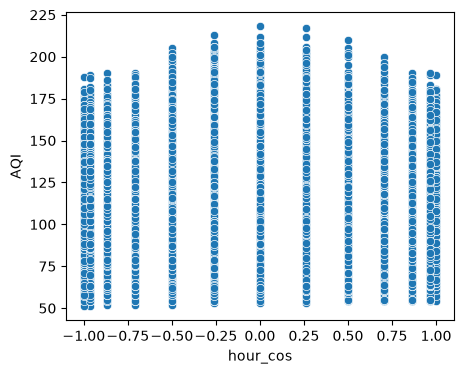

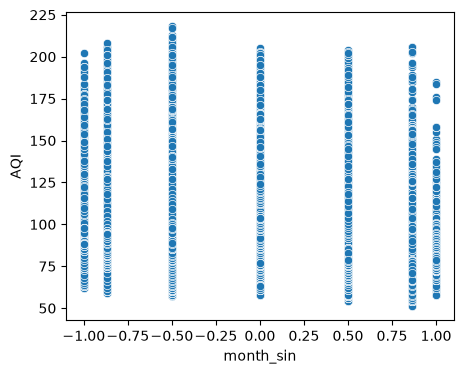

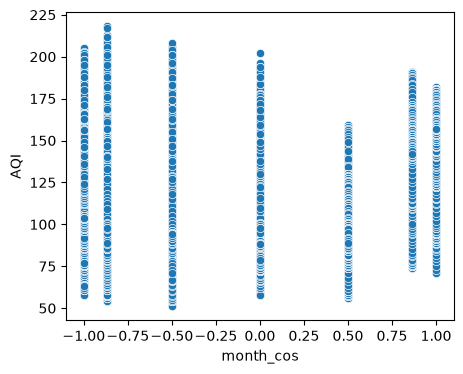

In [14]:
for column in df.columns:

    if column not in ["AQI","date"]:

        plt.figure(figsize=(5,4))

        sns.scatterplot(
            data=df,
            x=column,
            y="AQI"
        )

        plt.show()

## Analysis
### Only Pollutants have a linear relationship with AQI whereas weather featuree have weak relation or may be non linear relation which can be captured by deep learning or tree based models.

### Month feature importance for AQI,

AQI changes throughout the year because of changes in:
- Temperature
- Rainfall
- Wind speed
- Sunlight
- Traffic patterns
- Biomass burning
- Agricultural burning
- Industrial emissions

In [15]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

import numpy as np

# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Month cyclic encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


- 2π represents one complete circle (360°).
- month / 12 converts the month number into its fraction of the year.
- sin() gives the vertical coordinate.
- cos() gives the horizontal coordinate.

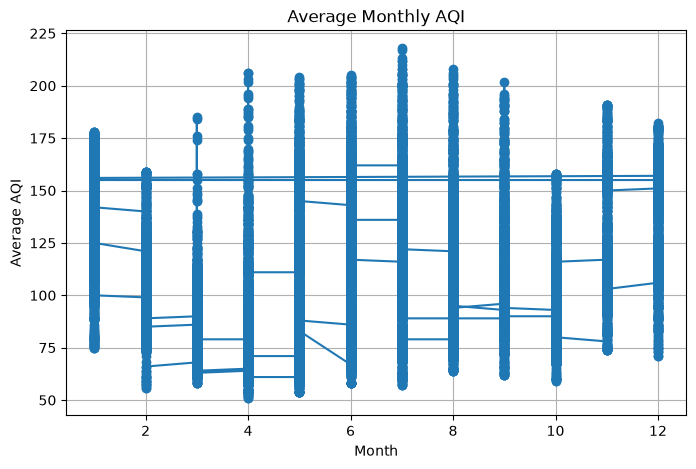

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["month"], df["AQI"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Average Monthly AQI")
plt.grid(True)
plt.show()

# Observations
## Winter (November–January)
### AQI is highest.
### This is common in many cities because:
### Cooler air can trap pollutants near the ground (temperature inversions).
### Lower wind speeds reduce dispersion.
### Additional emissions (heating, biomass burning, traffic) may contribute.
## Spring (March–April)
### AQI reaches its lowest levels.
### Likely due to better atmospheric mixing and fewer pollution episodes.
## Summer (June–July)
### AQI rises again.
### Hot weather and strong sunlight can increase ozone formation, and dry conditions can increase dust.
## Autumn (November)
### AQI increases sharply again, indicating a seasonal pollution pattern.

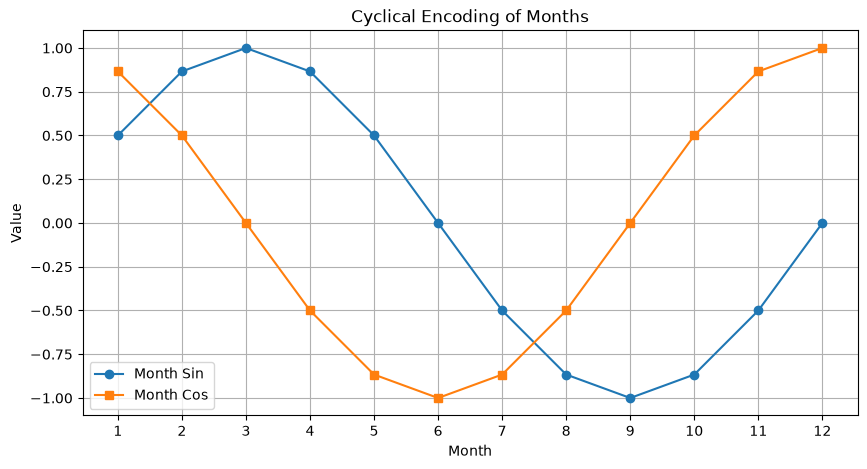

In [17]:
import matplotlib.pyplot as plt

month_features = (
    df[["month", "month_sin", "month_cos"]]
    .drop_duplicates()
    .sort_values("month")
)

plt.figure(figsize=(10,5))

plt.plot(
    month_features["month"],
    month_features["month_sin"],
    marker="o",
    label="Month Sin"
)

plt.plot(
    month_features["month"],
    month_features["month_cos"],
    marker="s",
    label="Month Cos"
)

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Months")
plt.grid(True)
plt.legend()

plt.show()

### Cyclic encoding

Cyclic encoding is a feature engineering technique used to represent cyclical (repeating) data such as:

Months (January → December → January)
Days of the week (Monday → Sunday → Monday)
Hours of the day (23:00 → 00:00)

It converts these values into sine and cosine values so that machine learning models understand their circular nature.

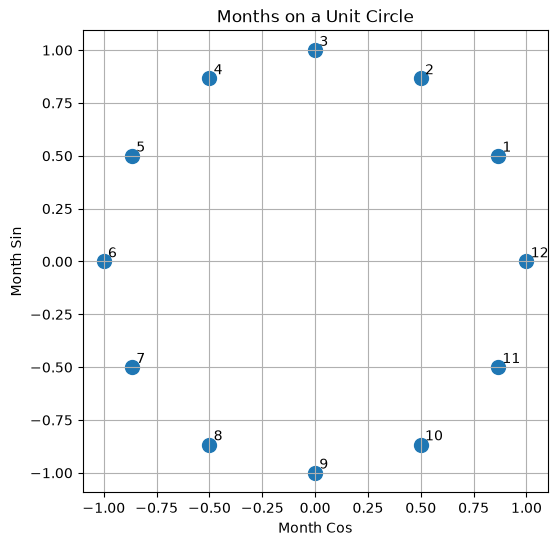

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(
    month_features["month_cos"],
    month_features["month_sin"],
    s=100
)

for _, row in month_features.iterrows():
    plt.text(
        row["month_cos"] + 0.02,
        row["month_sin"] + 0.02,
        str(int(row["month"]))
    )

plt.xlabel("Month Cos")
plt.ylabel("Month Sin")
plt.title("Months on a Unit Circle")
plt.grid(True)
plt.axis("equal")

plt.show()

# Reason of sin and cos of month.
### AQI has a seasonal pattern, replacing the raw month feature with month_sin and month_cos is a common feature engineering technique. It helps models like neural networks and linear regression understand that December and January are adjacent in time.

In [19]:
df.head()

,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,wind_speed_10m,datetime,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,...,ozone,AQI,hour_sin,hour_cos,month_sin,month_cos,hour,day,dayofweek,month
0,10.3,75,956.8,0.0,4.3,2024-01-01 00:00:00,73.3,107.8,2726.0,78.4,...,6.0,151,0.000000,1.000000,0.5,0.866025,0,1,0,1
1,8.7,79,956.3,0.0,5.9,2024-01-01 01:00:00,59.5,88.0,2447.0,68.7,...,6.0,151,0.258819,0.965926,0.5,0.866025,1,1,0,1
2,8.7,78,956.1,0.0,6.4,2024-01-01 02:00:00,47.6,71.0,2181.0,60.3,...,6.0,151,0.500000,0.866025,0.5,0.866025,2,1,0,1
3,10.6,69,956.8,0.0,4.0,2024-01-01 03:00:00,37.8,57.0,1914.0,52.5,...,6.0,151,0.707107,0.707107,0.5,0.866025,3,1,0,1
4,10.3,68,956.6,0.0,2.3,2024-01-01 04:00:00,30.2,46.1,1659.0,46.0,...,5.0,151,0.866025,0.500000,0.5,0.866025,4,1,0,1


In [20]:
df["AQI_change_rate"] = (
        df["AQI"].diff() / df["AQI"].shift(1)
    )

# Remove first row (NaN from shift)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [21]:
df.tail()

,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,wind_speed_10m,datetime,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,...,AQI,hour_sin,hour_cos,month_sin,month_cos,hour,day,dayofweek,month,AQI_change_rate
23418,28.1,81,945.3,0.0,7.3,2026-09-02 19:00:00,56.5,71.7,3311.0,89.8,...,168,-0.965926,0.258819,-1.0,-1.836970e-16,19,2,2,9,-0.023256
23419,27.5,80,946.0,0.0,7.5,2026-09-02 20:00:00,69.4,85.4,4164.0,120.0,...,149,-0.866025,0.500000,-1.0,-1.836970e-16,20,2,2,9,-0.113095
23420,26.9,82,946.6,0.0,6.1,2026-09-02 21:00:00,79.2,96.2,3814.0,127.8,...,110,-0.707107,0.707107,-1.0,-1.836970e-16,21,2,2,9,-0.261745
23421,26.4,84,946.5,0.0,5.8,2026-09-02 22:00:00,83.1,101.0,2832.0,123.1,...,95,-0.500000,0.866025,-1.0,-1.836970e-16,22,2,2,9,-0.136364
23422,26.0,86,946.5,0.0,6.5,2026-09-02 23:00:00,82.0,100.8,1939.0,112.3,...,98,-0.258819,0.965926,-1.0,-1.836970e-16,23,2,2,9,0.031579


In [22]:
print(df.columns)

Index(['temperature_2m', 'relative_humidity_2m', 'surface_pressure',
       'precipitation', 'wind_speed_10m', 'datetime', 'pm2_5', 'pm10',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'AQI', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'hour', 'day',
       'dayofweek', 'month', 'AQI_change_rate'],
      dtype='object')
